# L6 lab 3 · Assemble the controls conceptually

This lab joins the lecture's four controls: activation, initialization, normalization axis, and residual path. Each experiment is deliberately small and deterministic, uses only NumPy and Matplotlib, and downloads no data.

## 1. Predict four deep-network traces separately

For each configuration, predict the **forward RMS trace** and **backward RMS trace** through 24 layers:

1. sigmoid with $Var(w)=1$;
2. sigmoid with Xavier;
3. ReLU with Xavier;
4. ReLU with He.

Forward and backward behavior can disagree, so do not force one total ranking. Instead, name the configuration you expect to be healthiest on both traces and give a reason involving the weight multiplier and activation derivative. These are per-coordinate RMS gauges, not total vector norms.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Reuse lab 2's exact per-coordinate squared-gauge anchor.
ANCHOR_WIDTH, ANCHOR_DEPTH = 4, 5
ANCHOR_Q0 = ANCHOR_G5 = 1.0
ANCHOR_VARIANCES = {"Xavier": 1/4, "He": 0.5}
ANCHOR_C = {name: 0.5 * ANCHOR_WIDTH * var_w for name, var_w in ANCHOR_VARIANCES.items()}
print(f"width-4 squared-gauge anchor: q0={ANCHOR_Q0:g}, g5={ANCHOR_G5:g}")
for name in ANCHOR_VARIANCES:
    c = ANCHOR_C[name]
    print(f"{name:7s}: Var(w)={ANCHOR_VARIANCES[name]:g}, c={c:g}, q5=g0={c**ANCHOR_DEPTH:g}")
assert ANCHOR_C == {"Xavier": 0.5, "He": 1.0}
assert ANCHOR_C["Xavier"]**ANCHOR_DEPTH == 0.03125

BATCH, WIDTH, DEPTH = 256, 64, 24

def sigmoid(x):
    return 1/(1+np.exp(-np.clip(x, -40, 40)))

CONFIGS = {
    'sigmoid + Var(w)=1': (sigmoid, lambda u: sigmoid(u)*(1-sigmoid(u)), 1.0),
    'sigmoid + Xavier':  (sigmoid, lambda u: sigmoid(u)*(1-sigmoid(u)), 1/WIDTH),
    'ReLU + Xavier':     (lambda u: np.maximum(0,u), lambda u: (u>0), 1/WIDTH),
    'ReLU + He':         (lambda u: np.maximum(0,u), lambda u: (u>0), 2/WIDTH),
}

def trace_network(activation, derivative, var_w, seed=6):
    rng = np.random.default_rng(seed)
    h = rng.standard_normal((BATCH, WIDTH))
    hs, us, weights = [h], [], []
    for _ in range(DEPTH):
        W = rng.normal(0, np.sqrt(var_w), (WIDTH, WIDTH))
        u = h @ W.T
        h = activation(u)
        hs.append(h); us.append(u); weights.append(W)
    grad = rng.standard_normal(h.shape)
    grad_rms = [np.sqrt(np.mean(grad**2))]
    for W, u in zip(weights[::-1], us[::-1]):
        grad = (grad * derivative(u)) @ W
        grad_rms.append(np.sqrt(np.mean(grad**2)))
    act_rms = np.array([np.sqrt(np.mean(v**2)) for v in hs])
    return act_rms, np.array(grad_rms[::-1]) / grad_rms[0]

traces = {name: trace_network(*args) for name, args in CONFIGS.items()}

width-4 squared-gauge anchor: q0=1, g5=1
Xavier : Var(w)=0.25, c=0.5, q5=g0=0.03125
He     : Var(w)=0.5, c=1, q5=g0=1


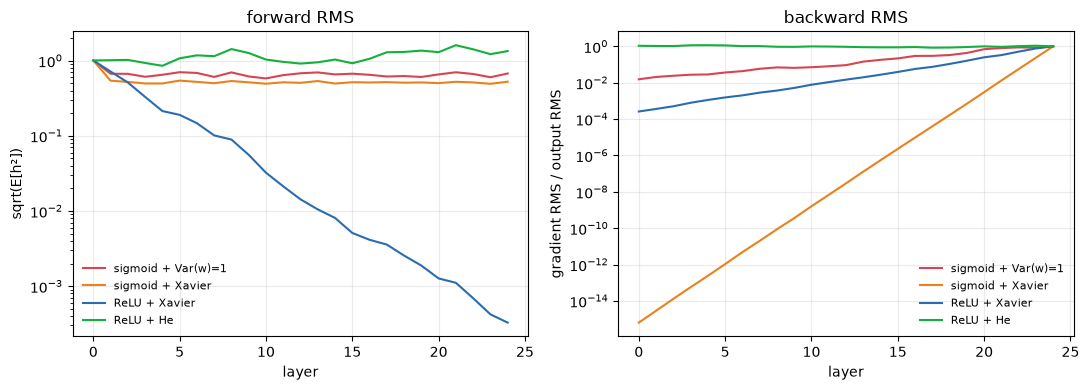

configuration              final activation RMS   input gradient ratio
sigmoid + Var(w)=1                    6.756e-01              1.548e-02
sigmoid + Xavier                      5.254e-01              6.430e-16
ReLU + Xavier                         3.276e-04              2.618e-04
ReLU + He                             1.342e+00              1.072e+00

first layer outside [0.1, 10] in propagation order
configuration              forward 0→24   backward 24→0
sigmoid + Var(w)=1                 none              12
sigmoid + Xavier                   none              22
ReLU + Xavier                         8              17
ReLU + He                          none            none


In [2]:
layers = np.arange(DEPTH+1)
colors = ['#D64550', '#EB811B', '#2B6CB0', '#14B03D']
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for (name, (act, grad)), color in zip(traces.items(), colors):
    axes[0].semilogy(layers, act, label=name, color=color)
    axes[1].semilogy(layers, grad, label=name, color=color)
axes[0].set(title='forward RMS', xlabel='layer', ylabel='sqrt(E[h²])')
axes[1].set(title='backward RMS', xlabel='layer', ylabel='gradient RMS / output RMS')
for ax in axes:
    ax.grid(alpha=.25); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

print(f"{'configuration':24s} {'final activation RMS':>22s} {'input gradient ratio':>22s}")
for name, (act, grad) in traces.items():
    print(f"{name:24s} {act[-1]:22.3e} {grad[0]:22.3e}")

def first_outside(trace, order, low=0.1, high=10):
    return next((layer for layer in order if not low <= trace[layer] <= high), "none")

print("\nfirst layer outside [0.1, 10] in propagation order")
print(f"{'configuration':24s} {'forward 0→24':>14s} {'backward 24→0':>15s}")
for name, (act, grad) in traces.items():
    forward_exit = first_outside(act, range(DEPTH + 1))
    backward_exit = first_outside(grad, range(DEPTH, -1, -1))
    print(f"{name:24s} {str(forward_exit):>14s} {str(backward_exit):>15s}")

**Inspect:** Compare the two exit columns rather than collapsing them into one rank. Forward is inspected from layer 0 to 24; backward is inspected from output layer 24 toward layer 0. A scheme can look reasonable for five layers and fail by layer twenty-four.

**Carry the anchor forward:** the width-4 values above are squared gauges: Xavier has $c=0.5$ and $q_5=g_0=0.03125$, while He has $c=1$ and both endpoints equal 1. The 24-layer experiment plots RMS, the square root of a squared gauge, so its numerical ratios are not $c^L$ itself.

## 2. Normalization is an axis choice

Rows are examples and columns are features. Start with the BatchNorm slice $[1,2,3,4]$: predict its population mean $\mu=2.5$ and variance $\sigma^2=1.25$. Then predict which entries share one mean/variance under BatchNorm and LayerNorm.

In [3]:
X = np.array([
    [1., 10., 100.],
    [2., 20., 200.],
    [3., 30., 300.],
    [4., 40., 400.],
])

def normalize(x, axis, eps=1e-5):
    mean = x.mean(axis=axis, keepdims=True)
    var = x.var(axis=axis, keepdims=True)
    return (x-mean)/np.sqrt(var+eps)

batch_norm = normalize(X, axis=0)  # down rows, one statistic per feature
layer_norm = normalize(X, axis=1)  # across columns, one statistic per example
bn_slice = X[:, 0]
slice_mean, slice_var = bn_slice.mean(), bn_slice.var()
np.set_printoptions(precision=3, suppress=True)
print(f"BatchNorm slice [1, 2, 3, 4]: mean={slice_mean:g}, variance={slice_var:g}")
print('X:'); print(X)
print('BatchNorm-like result (axis=0):'); print(batch_norm)
print('LayerNorm-like result (axis=1):'); print(layer_norm)

assert slice_mean == 2.5 and slice_var == 1.25
assert np.allclose(batch_norm.mean(axis=0), 0, atol=1e-7)
assert np.allclose(layer_norm.mean(axis=1), 0, atol=1e-7)

BatchNorm slice [1, 2, 3, 4]: mean=2.5, variance=1.25
X:
[[  1.  10. 100.]
 [  2.  20. 200.]
 [  3.  30. 300.]
 [  4.  40. 400.]]
BatchNorm-like result (axis=0):
[[-1.342 -1.342 -1.342]
 [-0.447 -0.447 -0.447]
 [ 0.447  0.447  0.447]
 [ 1.342  1.342  1.342]]
LayerNorm-like result (axis=1):
[[-0.805 -0.604  1.409]
 [-0.805 -0.604  1.409]
 [-0.805 -0.604  1.409]
 [-0.805 -0.604  1.409]]


**Explain:** If a fifth batch member is added, which existing outputs may change? Why does that matter at inference time for BatchNorm but not LayerNorm?

## 3. A residual route changes the local multiplier

Let a local branch have derivative $F'(x)=-0.1$. Before running, compare the five-block **gradient magnitudes** for a plain stack, $|{-0.1}|^5=10^{-5}$, and a residual stack, $|1-0.1|^5=0.9^5=0.59049$. These curves are scalar gradient-magnitude multipliers, not the squared gauges used in the width-4 anchor.

five-block plain magnitude:    0.00001
five-block residual magnitude: 0.59049


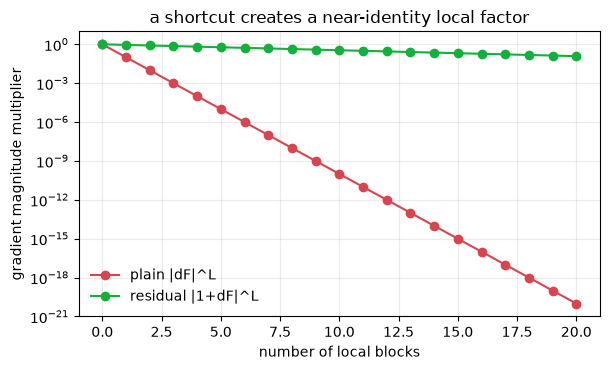

In [4]:
branch_derivative = -0.1
BLOCKS = 5
depths = np.arange(0, 21)
plain = np.abs(branch_derivative) ** depths
residual = np.abs(1 + branch_derivative) ** depths

plain_5 = np.abs(branch_derivative) ** BLOCKS
residual_5 = np.abs(1 + branch_derivative) ** BLOCKS
print(f"five-block plain magnitude:    {plain_5:.5f}")
print(f"five-block residual magnitude: {residual_5:.5f}")
assert np.isclose(plain_5, 1e-5)
assert np.isclose(residual_5, 0.59049)

fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.semilogy(depths, plain, 'o-', label='plain |dF|^L', color='#D64550')
ax.semilogy(depths, residual, 'o-', label='residual |1+dF|^L', color='#14B03D')
ax.set(xlabel='number of local blocks', ylabel='gradient magnitude multiplier', title='a shortcut creates a near-identity local factor')
ax.grid(alpha=.25); ax.legend(frameon=False); plt.tight_layout(); plt.show()

## 4. Final explanation

Complete this causal chain in your own words:

- activation controls __________;
- initialization controls __________ at step zero;
- normalization controls __________ during training over a chosen axis;
- a residual connection changes the local Jacobian from __________ to __________.

**Takeaway:** none of the four controls is magic. Conceptually, initialization sets the starting scale, normalization chooses and corrects a statistic, and a residual path adds an identity Jacobian route. Their effects should be checked with separate forward and backward measurements.